# Argument realization in an Ojibwe corpus: word order

In this notebook, we will attempt to parse the word order of overt nominals, currently touching 2 cases:
1. Transitive (Both arguments overt): Without splitting on specific attributes, what counts do we see of VOS, VSO, SVO etc.
2. One overt argument: For now just counting overall, will split on verb paradigm after.
3. Direct-inverse: Taking only 3-3 VTAs into account, what word orders do we see for the direct and inverse. 

### Part 1: Transitive word order counts

Scan the `.conllu` file for word order information. 

In [ ]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VSO_count = VOS_count = SVO_count = OVS_count = SOV_count = OSV_count = 0

# TODO: for now I only collect 1 subject and 1 object per sentence
#       and make sure that head matches. not good for embedded clauses etc.
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD

        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        # check that at least one subject and object are found
        if len(subjects) < 1 or len(objects) < 1:
            continue
        
        # build up subj/obj pairs where the head is the same ID
        subj_obj_pairs = []
        for subj in subjects:
            for obj in objects: 
                if subj[1] == obj[1]:
                    subj_obj_pairs.append((subj, obj))
        
        for subj, obj in subj_obj_pairs:
            # collect counts per case
            # VSO 
            if subj[0] > subj[1] and subj[0] < obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VSO: {sent.metadata.get("text")}")
                VSO_count += 1
                continue
            # VOS
            if subj[0] > subj[1] and subj[0] > obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VOS: {sent.metadata.get("text")}")
                VOS_count += 1
                continue
            # SVO 
            if subj[0] < subj[1] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is SVO: {sent.metadata.get("text")}")
                SVO_count += 1
                continue
            # OVS 
            if subj[0] > subj[1] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OVS: {sent.metadata.get("text")}")
                OVS_count += 1
                continue
            # SOV 
            if subj[0] < subj[1] and subj[0] < obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is SOV: {sent.metadata.get("text")}")
                SOV_count += 1
                continue
            # OSV 
            if subj[0] < subj[1] and subj[0] > obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OSV: {sent.metadata.get("text")}")
                OSV_count += 1
                continue

total_count = VSO_count + VOS_count + SVO_count + OVS_count + SOV_count + OSV_count
        
print(
    f"Total sentences w/ two overt arguments: {total_count}",
    f"Total VSO: {VSO_count}",
    f"Total VOS: {VOS_count}",
    f"Total SVO: {SVO_count}",
    f"Total OVS: {OVS_count}",
    f"Total SOV: {SOV_count}",
    f"Total OSV: {OSV_count}",
    sep="\n",
)


Sentence 28 is VSO: ingii-pizindawaag niin ingiw chi-aya'aag .
Sentence 32 is VSO: ingii-pizindawaag niin ingiw nichi-anishinaabemag .
Sentence 69 is SOV: gaawiin dash ge niin gegoo ingikendanziin , mashkiki gii-ozhitoowaad .
Sentence 70 is OVS: akina gegoo ogii-gikendaanaawaa mewinzha anishinaabeg .
Sentence 73 is OSV: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 73 is SVO: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 103 is OSV: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 120 is OSV: akina gegoo wiinawaa ogii-ozhitoonaawaa .
Sentence 140 is SVO: gaaw

In [3]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VSO", "total": VSO_count,},
    {"word order": "VOS", "total": VOS_count,},
    {"word order": "SVO", "total": SVO_count,},
    {"word order": "OVS", "total": OVS_count,},
    {"word order": "SOV", "total": SOV_count,},
    {"word order": "OSV", "total": OSV_count,},
]
df = pd.DataFrame(stats)
df["ratio"] = round(df["total"] / total_count, 2)

print(df.to_string(index=False))

word order  total  ratio
       VSO      4   0.12
       VOS      1   0.03
       SVO     14   0.44
       OVS      6   0.19
       SOV      2   0.06
       OSV      5   0.16


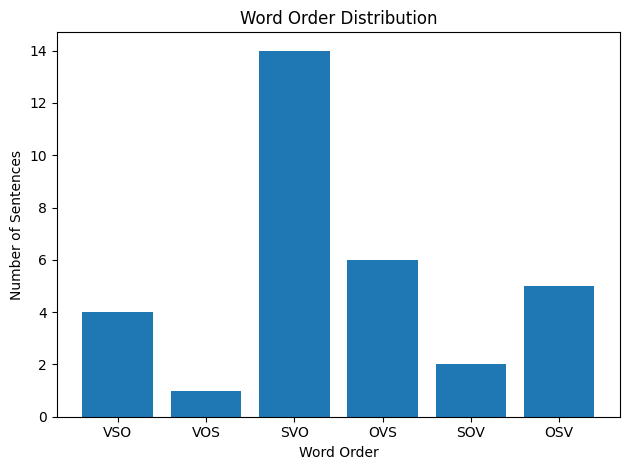

In [6]:
# Simple bar chart for word order distribution

import matplotlib.pyplot as plt
import numpy as np

# Data
orders = ["VSO", "VOS", "SVO", "OVS", "SOV", "OSV"]
totals = np.array([4, 1, 14, 6, 2, 5])

# Create plot
plt.figure()
plt.bar(orders, totals)

plt.xlabel("Word Order")
plt.ylabel("Number of Sentences")
plt.title("Word Order Distribution")

plt.tight_layout()
plt.show()


### Part 2: One overt argument word order

Similar logic to above, collect counts for different orders.

In [ ]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)


Total VS: 119
Total SV: 109
Total VO: 161
Total OV: 111


In [5]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VS", "total": VS_count,},
    {"word order": "SV", "total": SV_count,},
    {"word order": "VO", "total": VO_count,},
    {"word order": "OV", "total": OV_count,},
]
df = pd.DataFrame(stats)
print(df.to_string(index=False))

word order  total
        VS    119
        SV    109
        VO    161
        OV    111


### Part 3: Word order of direct and inverse

Sampling only VTA verbs, count word orders splitting on direct and inverse morphology.

In [ ]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)


### Part 4: Overt subject word order split on subject type

A. Form/type of overt subject
- Personal pronoun: 1p, 2p, or 3p personal pronoun as subject.
- Bare noun: A single common noun attaches as subject.
- Proper noun/name: A proper name attaches as subject.
- Bare demonstrative: A single demonstrative attaches as subject.
- Bare indefinite pronoun: A single indefinite pronoun attaches as subject.
- Demonstrative + indefinite pronoun: Subject is a demonstrative plus an indefinite
- Headless RC: A relative clause attaches directly as subject.
- Demonstrative + RC: A demonstrative plus relative clause functions as subject.
- Demonstrative + noun: A demonstrative plus noun functions as subject.
- Noun + RC: A noun plus relative clause functions as subject.
- Quantified/numeral subject: A quantifier, numeral, or quantified phrase functions as subject.
- Demonstrative + noun + RC: The subject is a complex DP with a demonstrative, noun, and relative clause.
- Coordinated subject: A coordinated DP/NP functions as subject. [Technically a superset of other cases, but we select this one first]
- Other complex nominal subject: Any overt subject not captured above (not sure if needed).

B. Agreement/person/animacy status of subject
- SAP subject: 1p or 2p subject.
- Third-person subject: 3p subject.
- Animate subject: Any animate subject, including complex DPs and RCs with animate heads.
- Inanimate subject: Any inanimate subject, including complex DPs and RCs with inanimate heads.
- Obviative subject: Any obviative subject, including complex DPs and RCs with obviative heads.

In [5]:
from grammar_modules.disambiguation import REPO_ROOT
from conllu import parse_incr
from collections import Counter, defaultdict

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"


def is_real_token(tok):
    """
    Skip multiword token ranges like 3-4 and empty nodes like 5.1.
    We only want normal integer token IDs.
    """
    return isinstance(tok.get("id"), int)


def get_feats(tok):
    feats = tok.get("feats")
    return feats if isinstance(feats, dict) else {}


def is_demonstrative(tok):
    """
    Adjust this if your demonstratives are tagged differently.
    This catches ordinary UD-style demonstratives.
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""
    feats = get_feats(tok)

    return (
        feats.get("PronType") == "Dem"
        or "Dem" in xpos
        or upos == "DET" and feats.get("PronType") == "Dem"
    )


def is_personal_pronoun(tok):
    """
    Personal pronouns: 1p, 2p, or 3p pronouns.
    Excludes demonstratives.
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""

    person_markers = {
        "1Sg", "2Sg", "3Sg",
        "1Pl", "2Pl", "3Pl",
        "1", "2", "3",
    }

    xpos_parts = set(xpos.split("|"))

    return (
        upos == "PRON"
        and "PRONPer" in xpos_parts
        and bool(person_markers & xpos_parts)
        and not is_demonstrative(tok)
    )


def is_indefinite_pronoun(tok):
    """
    Indefinite pronouns in the current treebank look like:

    awiiya   PRON   PRONIndf|NA|PRON
    gegoo    PRON   PRONIndf|NI|PRON
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""
    xpos_parts = set(xpos.split("|"))

    return (
        upos == "PRON"
        and "PRONIndf" in xpos_parts
    )

def is_common_noun(tok):
    return tok.get("upos") == "NOUN"


def is_proper_noun(tok):
    return tok.get("upos") == "PROPN"


def is_quant_or_numeral(tok):
    """
    Adjust as needed depending on your treebank.
    """
    upos = tok.get("upos")
    deprel = tok.get("deprel") or ""
    xpos = tok.get("xpos") or ""
    feats = get_feats(tok)

    return (
        upos == "NUM"
        or deprel in {"nummod", "det:numgov", "det:nummod", "quantmod"}
        or feats.get("NumType") is not None
        or "Quant" in xpos
    )


def is_coordination_marker(tok):
    deprel = tok.get("deprel") or ""
    return deprel in {"conj", "cc"}


def is_rc_token(tok):
    """
    THIS IS THE MAIN FUNCTION YOU MAY NEED TO CHANGE.

    Current assumptions:
    - relative clauses may be marked by deprel acl:relcl
    - Ojibwe participial/relative forms may have Pcp in xpos
    """
    deprel = tok.get("deprel") or ""
    xpos = tok.get("xpos") or ""

    return (
        deprel == "acl:relcl"
        or "+Pcp" in xpos
        or "Pcp" in xpos
    )


def build_children(sent):
    children = defaultdict(list)

    for tok in sent:
        if not is_real_token(tok):
            continue

        head = tok.get("head")
        if isinstance(head, int):
            children[head].append(tok)

    return children


def get_subtree(tok_id, children):
    """
    Return all tokens dominated by tok_id, including tok_id's descendants.
    Does not include tok_id itself unless added separately outside.
    """
    descendants = []

    for child in children.get(tok_id, []):
        descendants.append(child)
        descendants.extend(get_subtree(child["id"], children))

    return descendants


def get_subject_expression(subj_tok, children):
    """
    Approximate the maximal overt subject expression as the subject token
    plus its dependency descendants.

    This is useful for detecting things like:
    - demonstrative + noun
    - noun + RC
    - demonstrative + noun + RC
    - coordination
    - quantifier/numeral subjects
    """
    return [subj_tok] + get_subtree(subj_tok["id"], children)


def subject_bucket(subj_tok, subject_expression):
    """
    Assign exactly one mutually exclusive bucket.

    Priority order:
    1. Coordinated subject
    2. Quantified/numeral subject
    3. Demonstrative + noun + RC
    4. Demonstrative + RC
    5. Demonstrative + noun
    6. Noun + RC
    7. Demonstrative + indefinite pronoun
    8. Headless RC
    9. Personal pronoun
    10. Bare indefinite pronoun
    11. Proper noun/name
    12. Bare noun
    13. Bare demonstrative
    14. Other complex nominal subject
    """

    has_coord = any(is_coordination_marker(tok) for tok in subject_expression)
    has_quant = any(is_quant_or_numeral(tok) for tok in subject_expression)
    has_dem = any(is_demonstrative(tok) for tok in subject_expression)
    has_indef_pron = any(is_indefinite_pronoun(tok) for tok in subject_expression)
    has_common_noun = any(is_common_noun(tok) for tok in subject_expression)
    has_proper_noun = any(is_proper_noun(tok) for tok in subject_expression)
    has_noun = has_common_noun or has_proper_noun
    has_rc = any(is_rc_token(tok) for tok in subject_expression)

    expression_len = len(subject_expression)

    if has_coord:
        return "Coordinated subject"

    if has_quant:
        return "Quantified/numeral subject"

    if has_dem and has_noun and has_rc:
        return "Demonstrative + noun + RC"

    if has_dem and has_rc and not has_noun:
        return "Demonstrative + RC"

    if has_dem and has_noun and not has_rc:
        return "Demonstrative + noun"

    if has_noun and has_rc and not has_dem:
        return "Noun + RC"

    if has_rc and not has_noun and not has_dem:
        return "Headless RC"

    if has_dem and has_indef_pron:
        return "Demonstrative + indefinite pronoun"

    if expression_len == 1 and is_personal_pronoun(subj_tok):
        return "Personal pronoun"

    if expression_len == 1 and is_indefinite_pronoun(subj_tok):
        return "Bare indefinite pronoun"

    if expression_len == 1 and is_proper_noun(subj_tok):
        return "Proper noun/name"

    if expression_len == 1 and is_common_noun(subj_tok):
        return "Bare noun"

    if expression_len == 1 and is_demonstrative(subj_tok):
        return "Bare demonstrative"

    return "Other complex nominal subject"


def subject_position(subj_tok, subject_expression):
    """
    Returns SV / VS based on the span of the whole subject expression
    relative to its head verb.

    SV = whole subject expression is before the verb
    VS = whole subject expression is after the verb
    STRADDLE = subject expression occurs on both sides of the verb
    UNKNOWN = missing/non-integer head
    """
    head_id = subj_tok.get("head")

    if not isinstance(head_id, int):
        return "UNKNOWN"

    token_ids = [tok["id"] for tok in subject_expression if is_real_token(tok)]

    if not token_ids:
        return "UNKNOWN"

    min_id = min(token_ids)
    max_id = max(token_ids)

    if max_id < head_id:
        return "SV"
    elif min_id > head_id:
        return "VS"
    else:
        return "STRADDLE"


bucket_counts = Counter()
bucket_position_counts = defaultdict(Counter)
examples = defaultdict(list)

with open(CORPUS_PATH, encoding="utf-8") as f:
    for sent_index, sent in enumerate(parse_incr(f), start=1):
        children = build_children(sent)

        sent_id = sent.metadata.get("sent_id", f"sent_{sent_index}")
        text = sent.metadata.get("text", "")

        for tok in sent:
            if not is_real_token(tok):
                continue

            if tok.get("deprel") != "nsubj":
                continue

            subj_expr = get_subject_expression(tok, children)
            bucket = subject_bucket(tok, subj_expr)
            position = subject_position(tok, subj_expr)

            bucket_counts[bucket] += 1
            bucket_position_counts[bucket][position] += 1

            # Save a few examples per bucket for checking
            if len(examples[bucket]) < 5:
                subj_words = " ".join(
                    t.get("form", "") for t in sorted(subj_expr, key=lambda x: x["id"])
                )

                head_id = tok.get("head")
                head_tok = next(
                    (t for t in sent if is_real_token(t) and t["id"] == head_id),
                    None
                )
                head_form = head_tok.get("form") if head_tok else "?"

                examples[bucket].append(
                    {
                        "sent_id": sent_id,
                        "position": position,
                        "subject": subj_words,
                        "head": head_form,
                        "text": text,
                    }
                )


print("Subject bucket counts")
print("=====================")

for bucket, count in bucket_counts.most_common():
    sv = bucket_position_counts[bucket]["SV"]
    vs = bucket_position_counts[bucket]["VS"]
    straddle = bucket_position_counts[bucket]["STRADDLE"]
    unknown = bucket_position_counts[bucket]["UNKNOWN"]

    print(f"{bucket}: {count}")
    print(f"  SV: {sv}")
    print(f"  VS: {vs}")
    print(f"  STRADDLE: {straddle}")
    print(f"  UNKNOWN: {unknown}")
    print()


print("\nExamples")
print("========")

for bucket in bucket_counts:
    print(f"\n{bucket}")
    print("-" * len(bucket))

    for ex in examples[bucket]:
        print(f"{ex['sent_id']} | {ex['position']}")
        print(f"  subject: {ex['subject']}")
        print(f"  head: {ex['head']}")
        print(f"  text: {ex['text']}")

Subject bucket counts
Bare noun: 62
  SV: 36
  VS: 26
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + noun: 61
  SV: 15
  VS: 46
  STRADDLE: 0
  UNKNOWN: 0

Bare demonstrative: 42
  SV: 16
  VS: 26
  STRADDLE: 0
  UNKNOWN: 0

Personal pronoun: 26
  SV: 18
  VS: 8
  STRADDLE: 0
  UNKNOWN: 0

Bare indefinite pronoun: 14
  SV: 13
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0

Headless RC: 8
  SV: 0
  VS: 8
  STRADDLE: 0
  UNKNOWN: 0

Other complex nominal subject: 8
  SV: 7
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0

Quantified/numeral subject: 4
  SV: 4
  VS: 0
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + RC: 2
  SV: 0
  VS: 2
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + indefinite pronoun: 1
  SV: 0
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0


Examples

Bare noun
---------
3 | VS
  subject: ozagaskwaajimeg
  head: baataniinowag
  text: naaniibowa gaawiin ogikendanziinaawaa iw baataniinowag imaa ozagaskwaajimeg , ge-sh giiwenh gaa-izhiwebak jibwaa-dagoshinowaad chi-mookomaanag imaa .
5 | VS
  subject: anishinaabeg
  hea

In [6]:
from grammar_modules.disambiguation import REPO_ROOT
from conllu import parse_incr
from collections import Counter, defaultdict

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

In [7]:
def is_real_token(tok):
    """
    Skip multiword token ranges like 3-4 and empty nodes like 5.1.
    We only want normal integer token IDs.
    """
    return isinstance(tok.get("id"), int)


def get_feats(tok):
    feats = tok.get("feats")
    return feats if isinstance(feats, dict) else {}


def is_demonstrative(tok):
    """
    Adjust this if your demonstratives are tagged differently.
    This catches ordinary UD-style demonstratives.
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""
    feats = get_feats(tok)

    return (
        feats.get("PronType") == "Dem"
        or "Dem" in xpos
        or upos == "DET" and feats.get("PronType") == "Dem"
    )


def is_personal_pronoun(tok):
    """
    Personal pronouns: 1p, 2p, or 3p pronouns.
    Excludes demonstratives.
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""

    person_markers = {
        "1Sg", "2Sg", "3Sg",
        "1Pl", "2Pl", "3Pl",
        "1", "2", "3",
    }

    xpos_parts = set(xpos.split("|"))

    return (
        upos == "PRON"
        and "PRONPer" in xpos_parts
        and bool(person_markers & xpos_parts)
        and not is_demonstrative(tok)
    )


def is_indefinite_pronoun(tok):
    """
    Indefinite pronouns in the current treebank look like:

    awiiya   PRON   PRONIndf|NA|PRON
    gegoo    PRON   PRONIndf|NI|PRON
    """
    upos = tok.get("upos")
    xpos = tok.get("xpos") or ""
    xpos_parts = set(xpos.split("|"))

    return (
        upos == "PRON"
        and "PRONIndf" in xpos_parts
    )

def is_common_noun(tok):
    return tok.get("upos") == "NOUN"


def is_proper_noun(tok):
    return tok.get("upos") == "PROPN"


def is_quant_or_numeral(tok):
    """
    Adjust as needed depending on your treebank.
    """
    upos = tok.get("upos")
    deprel = tok.get("deprel") or ""
    xpos = tok.get("xpos") or ""
    feats = get_feats(tok)

    return (
        upos == "NUM"
        or deprel in {"nummod", "det:numgov", "det:nummod", "quantmod"}
        or feats.get("NumType") is not None
        or "Quant" in xpos
    )


def is_coordination_marker(tok):
    deprel = tok.get("deprel") or ""
    return deprel in {"conj", "cc"}


def is_rc_token(tok):
    """
    THIS IS THE MAIN FUNCTION YOU MAY NEED TO CHANGE.

    Current assumptions:
    - relative clauses may be marked by deprel acl:relcl
    - Ojibwe participial/relative forms may have Pcp in xpos
    """
    deprel = tok.get("deprel") or ""
    xpos = tok.get("xpos") or ""

    return (
        deprel == "acl:relcl"
        or "+Pcp" in xpos
        or "Pcp" in xpos
    )

In [8]:
def xpos_parts(tok):
    xpos = tok.get("xpos") or ""
    return set(xpos.split("|"))


def is_sap_token(tok):
    parts = xpos_parts(tok)

    sap_markers = {
        "1Sg", "2Sg", "1Pl", "2Pl",
        "1SgSubj", "2SgSubj", "1PlSubj", "2PlSubj",
        "ExclSubj", "InclSubj",
    }

    return bool(parts & sap_markers)


def is_third_person_token(tok):
    parts = xpos_parts(tok)

    third_markers = {
        "3Sg", "3Pl",
        "3SgProxSubj", "3PlProxSubj",
        "3SgObvSubj", "3PlObvSubj",
        "0SgSubj", "0PlSubj",
    }

    return bool(parts & third_markers)


def is_animate_token(tok):
    parts = xpos_parts(tok)

    return (
        "NA" in parts
        or "3SgProxSubj" in parts
        or "3PlProxSubj" in parts
        or "3SgObvSubj" in parts
        or "3PlObvSubj" in parts
    )


def is_inanimate_token(tok):
    parts = xpos_parts(tok)

    return (
        "NI" in parts
        or "0SgSubj" in parts
        or "0PlSubj" in parts
    )


def is_obviative_token(tok):
    parts = xpos_parts(tok)

    return (
        "Obv" in parts
        or "ObvSg" in parts
        or "ObvPl" in parts
        or "3SgObvSubj" in parts
        or "3PlObvSubj" in parts
    )


def subject_status_labels(subj_tok, subject_expression, head_tok=None):
    labels = set()

    if any(is_sap_token(tok) for tok in subject_expression):
        labels.add("SAP subject")

    if any(is_third_person_token(tok) for tok in subject_expression):
        labels.add("Third-person subject")

    if any(is_animate_token(tok) for tok in subject_expression):
        labels.add("Animate subject")

    if any(is_inanimate_token(tok) for tok in subject_expression):
        labels.add("Inanimate subject")

    if any(is_obviative_token(tok) for tok in subject_expression):
        labels.add("Obviative subject")

    if head_tok is not None:
        if is_sap_token(head_tok):
            labels.add("SAP subject")

        if is_third_person_token(head_tok):
            labels.add("Third-person subject")

        if is_animate_token(head_tok):
            labels.add("Animate subject")

        if is_inanimate_token(head_tok):
            labels.add("Inanimate subject")

        if is_obviative_token(head_tok):
            labels.add("Obviative subject")

    return labels

In [9]:
def build_children(sent):
    children = defaultdict(list)

    for tok in sent:
        if not is_real_token(tok):
            continue

        head = tok.get("head")
        if isinstance(head, int):
            children[head].append(tok)

    return children


def get_subtree(tok_id, children):
    """
    Return all tokens dominated by tok_id, including tok_id's descendants.
    Does not include tok_id itself unless added separately outside.
    """
    descendants = []

    for child in children.get(tok_id, []):
        descendants.append(child)
        descendants.extend(get_subtree(child["id"], children))

    return descendants


def get_subject_expression(subj_tok, children):
    """
    Approximate the maximal overt subject expression as the subject token
    plus its dependency descendants.

    This is useful for detecting things like:
    - demonstrative + noun
    - noun + RC
    - demonstrative + noun + RC
    - coordination
    - quantifier/numeral subjects
    """
    return [subj_tok] + get_subtree(subj_tok["id"], children)

In [10]:
def subject_bucket(subj_tok, subject_expression):
    """
    Assign exactly one mutually exclusive bucket.

    Priority order:
    1. Coordinated subject
    2. Quantified/numeral subject
    3. Demonstrative + noun + RC
    4. Demonstrative + RC
    5. Demonstrative + noun
    6. Noun + RC
    7. Demonstrative + indefinite pronoun
    8. Headless RC
    9. Personal pronoun
    10. Bare indefinite pronoun
    11. Proper noun/name
    12. Bare noun
    13. Bare demonstrative
    14. Other complex nominal subject
    """

    has_coord = any(is_coordination_marker(tok) for tok in subject_expression)
    has_quant = any(is_quant_or_numeral(tok) for tok in subject_expression)
    has_dem = any(is_demonstrative(tok) for tok in subject_expression)
    has_indef_pron = any(is_indefinite_pronoun(tok) for tok in subject_expression)
    has_common_noun = any(is_common_noun(tok) for tok in subject_expression)
    has_proper_noun = any(is_proper_noun(tok) for tok in subject_expression)
    has_noun = has_common_noun or has_proper_noun
    has_rc = any(is_rc_token(tok) for tok in subject_expression)

    expression_len = len(subject_expression)

    if has_coord:
        return "Coordinated subject"

    if has_quant:
        return "Quantified/numeral subject"

    if has_dem and has_noun and has_rc:
        return "Demonstrative + noun + RC"

    if has_dem and has_rc and not has_noun:
        return "Demonstrative + RC"

    if has_dem and has_noun and not has_rc:
        return "Demonstrative + noun"

    if has_noun and has_rc and not has_dem:
        return "Noun + RC"

    if has_rc and not has_noun and not has_dem:
        return "Headless RC"

    if has_dem and has_indef_pron:
        return "Demonstrative + indefinite pronoun"

    if expression_len == 1 and is_personal_pronoun(subj_tok):
        return "Personal pronoun"

    if expression_len == 1 and is_indefinite_pronoun(subj_tok):
        return "Bare indefinite pronoun"

    if expression_len == 1 and is_proper_noun(subj_tok):
        return "Proper noun/name"

    if expression_len == 1 and is_common_noun(subj_tok):
        return "Bare noun"

    if expression_len == 1 and is_demonstrative(subj_tok):
        return "Bare demonstrative"

    return "Other complex nominal subject"


def subject_position(subj_tok, subject_expression):
    """
    Returns SV / VS based on the span of the whole subject expression
    relative to its head verb.

    SV = whole subject expression is before the verb
    VS = whole subject expression is after the verb
    STRADDLE = subject expression occurs on both sides of the verb
    UNKNOWN = missing/non-integer head
    """
    head_id = subj_tok.get("head")

    if not isinstance(head_id, int):
        return "UNKNOWN"

    token_ids = [tok["id"] for tok in subject_expression if is_real_token(tok)]

    if not token_ids:
        return "UNKNOWN"

    min_id = min(token_ids)
    max_id = max(token_ids)

    if max_id < head_id:
        return "SV"
    elif min_id > head_id:
        return "VS"
    else:
        return "STRADDLE"

In [11]:
bucket_counts = Counter()
bucket_position_counts = defaultdict(Counter)
examples = defaultdict(list)

status_counts = Counter()
status_position_counts = defaultdict(Counter)
status_examples = defaultdict(list)

with open(CORPUS_PATH, encoding="utf-8") as f:
    for sent_index, sent in enumerate(parse_incr(f), start=1):
        children = build_children(sent)

        sent_id = sent.metadata.get("sent_id", f"sent_{sent_index}")
        text = sent.metadata.get("text", "")

        for tok in sent:
            if not is_real_token(tok):
                continue

            if tok.get("deprel") != "nsubj":
                continue

            subj_expr = get_subject_expression(tok, children)
            bucket = subject_bucket(tok, subj_expr)
            position = subject_position(tok, subj_expr)

            head_id = tok.get("head")
            head_tok = next(
                (t for t in sent if is_real_token(t) and t["id"] == head_id),
                None
            )

            status_labels = subject_status_labels(tok, subj_expr, head_tok=head_tok)

            bucket_counts[bucket] += 1
            bucket_position_counts[bucket][position] += 1

            for status in status_labels:
                status_counts[status] += 1
                status_position_counts[status][position] += 1

            # Save a few examples per bucket for checking
            if len(examples[bucket]) < 5:
                subj_words = " ".join(
                    t.get("form", "") for t in sorted(subj_expr, key=lambda x: x["id"])
                )

                head_form = head_tok.get("form") if head_tok else "?"

                examples[bucket].append(
                    {
                        "sent_id": sent_id,
                        "position": position,
                        "subject": subj_words,
                        "head": head_form,
                        "text": text,
                    }
                )

            if len(status_labels) > 0:
                for status in status_labels:
                    if len(status_examples[status]) < 5:
                        subj_words = " ".join(
                            t.get("form", "") for t in sorted(subj_expr, key=lambda x: x["id"])
                        )

                        head_form = head_tok.get("form") if head_tok else "?"

                        status_examples[status].append(
                            {
                                "sent_id": sent_id,
                                "position": position,
                                "subject": subj_words,
                                "head": head_form,
                                "text": text,
                            }
                        )

In [13]:
print("Subject bucket counts")
print("=====================")

for bucket, count in bucket_counts.most_common():
    sv = bucket_position_counts[bucket]["SV"]
    vs = bucket_position_counts[bucket]["VS"]
    straddle = bucket_position_counts[bucket]["STRADDLE"]
    unknown = bucket_position_counts[bucket]["UNKNOWN"]

    print(f"{bucket}: {count}")
    print(f"  SV: {sv}")
    print(f"  VS: {vs}")
    print(f"  STRADDLE: {straddle}")
    print(f"  UNKNOWN: {unknown}")
    print()


print("\nExamples")
print("========")

for bucket in bucket_counts:
    print(f"\n{bucket}")
    print("-" * len(bucket))

    for ex in examples[bucket]:
        print(f"{ex['sent_id']} | {ex['position']}")
        print(f"  subject: {ex['subject']}")
        print(f"  head: {ex['head']}")
        print(f"  text: {ex['text']}")

Subject bucket counts
Bare noun: 62
  SV: 36
  VS: 26
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + noun: 61
  SV: 15
  VS: 46
  STRADDLE: 0
  UNKNOWN: 0

Bare demonstrative: 42
  SV: 16
  VS: 26
  STRADDLE: 0
  UNKNOWN: 0

Personal pronoun: 26
  SV: 18
  VS: 8
  STRADDLE: 0
  UNKNOWN: 0

Bare indefinite pronoun: 14
  SV: 13
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0

Headless RC: 8
  SV: 0
  VS: 8
  STRADDLE: 0
  UNKNOWN: 0

Other complex nominal subject: 8
  SV: 7
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0

Quantified/numeral subject: 4
  SV: 4
  VS: 0
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + RC: 2
  SV: 0
  VS: 2
  STRADDLE: 0
  UNKNOWN: 0

Demonstrative + indefinite pronoun: 1
  SV: 0
  VS: 1
  STRADDLE: 0
  UNKNOWN: 0


Examples

Bare noun
---------
3 | VS
  subject: ozagaskwaajimeg
  head: baataniinowag
  text: naaniibowa gaawiin ogikendanziinaawaa iw baataniinowag imaa ozagaskwaajimeg , ge-sh giiwenh gaa-izhiwebak jibwaa-dagoshinowaad chi-mookomaanag imaa .
5 | VS
  subject: anishinaabeg
  hea

In [15]:
print("\nSubject status counts")
print("=====================")

for status, count in status_counts.most_common():
    sv = status_position_counts[status]["SV"]
    vs = status_position_counts[status]["VS"]
    straddle = status_position_counts[status]["STRADDLE"]
    unknown = status_position_counts[status]["UNKNOWN"]

    print(f"{status}: {count}")
    print(f"  SV: {sv}")
    print(f"  VS: {vs}")
    print(f"  STRADDLE: {straddle}")
    print(f"  UNKNOWN: {unknown}")
    print()


print("\nStatus examples")
print("===============")

for status in status_counts:
    print(f"\n{status}")
    print("-" * len(status))

    for ex in status_examples[status]:
        print(f"{ex['sent_id']} | {ex['position']}")
        print(f"  subject: {ex['subject']}")
        print(f"  head: {ex['head']}")
        print(f"  text: {ex['text']}")


Subject status counts
Third-person subject: 206
  SV: 92
  VS: 114
  STRADDLE: 0
  UNKNOWN: 0

Animate subject: 192
  SV: 96
  VS: 96
  STRADDLE: 0
  UNKNOWN: 0

Inanimate subject: 37
  SV: 13
  VS: 24
  STRADDLE: 0
  UNKNOWN: 0

SAP subject: 25
  SV: 17
  VS: 8
  STRADDLE: 0
  UNKNOWN: 0

Obviative subject: 4
  SV: 1
  VS: 3
  STRADDLE: 0
  UNKNOWN: 0


Status examples

Third-person subject
--------------------
3 | VS
  subject: ozagaskwaajimeg
  head: baataniinowag
  text: naaniibowa gaawiin ogikendanziinaawaa iw baataniinowag imaa ozagaskwaajimeg , ge-sh giiwenh gaa-izhiwebak jibwaa-dagoshinowaad chi-mookomaanag imaa .
5 | VS
  subject: anishinaabeg
  head: gaa-taawaad
  text: aanish naa mii imaa gaa-taawaad anishinaabeg .
11 | SV
  subject: anishinaabeg
  head: gii-waabamaawaad
  text: gaye anishinaabeg gii-waabamaawaad idi .
13 | SV
  subject: iw
  head: wenda-awibaa
  text: mii-sa iw wenda-awibaa nage gegoo onji aanakwad .
13 | VS
  subject: gegoo
  head: wenda-awibaa
  text: mi

### Part 5: Overt object word order split on object type

If object is realized, is this argument more pre-verbal or post-verbal. We query these cases:
- Personal pronoun: 1p, 2p, 3p personal pronoun objects. e.g.: 
- Bare noun: A single overt noun as an object. e.g.:  
- Bare demonstrative: A single overt demonstrative as an object. e.g.: 
